In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

In [2]:
# Import cleaned CSV

filepath = "../data/spike_waveforms_clean.csv"
df = pd.read_csv(
    filepath,
    header=None
)
print("Shape:", df.shape)
display(df.head())

Shape: (26862, 62)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61
0,28.708333,24.775000,2.341667,0.741667,12.741667,0.708333,-11.291667,-10.891667,2.308333,-0.891667,-6.491667,-11.358333,-27.391667,-23.858333,-15.425000,-13.358333,-2.091667,2.241667,13.008333,35.475000,43.541667,54.775000,69.975000,71.608333,85.575000,86.375000,84.008333,86.408333,75.175000,88.808333,96.408333,3392.475,3289.441667,2714.641667,2339.641667,2006.508333,1767.541667,1590.408333,1441.041667,1287.075000,1162.475000,1005.008333,894.108333,792.775000,704.975000,577.275000,470.608333,381.641667,300.275000,237.808333,176.108333,108.441667,52.741667,19.941667,-11.258333,8.741667,1.508333,-37.425000,-87.458333,-107.858333,-139.025000,-140.758333
1,32.623333,14.990000,5.756667,16.190000,2.623333,4.156667,2.923333,16.623333,11.323333,-10.710000,-16.710000,-4.643333,-9.843333,-23.376667,-15.776667,-8.276667,-9.043333,-12.643333,0.890000,2.923333,22.156667,4.090000,-17.176667,-39.576667,-166.676667,-271.710000,-293.310000,-304.643333,-259.676667,-127.776667,18.956667,150.690,256.756667,347.756667,382.590000,372.523333,329.223333,300.790000,255.523333,206.656667,183.423333,147.856667,85.356667,61.356667,36.190000,24.156667,4.923333,-3.843333,3.756667,-10.643333,-32.376667,-32.776667,-35.976667,-12.776667,-16.310000,-1.110000,0.156667,8.956667,8.090000,4.890000,3.290000,7.356667
2,-32.421667,-33.255000,-18.421667,-8.455000,-12.821667,-4.821667,-12.088333,11.111667,21.945000,24.778333,0.811667,3.645000,24.478333,24.811667,4.378333,-16.388333,-7.555000,1.578333,4.345000,24.345000,52.845000,41.245000,37.678333,-14.021667,-124.155000,-215.221667,-230.988333,-216.521667,-187.521667,-109.821667,0.711667,120.545,226.611667,290.245000,299.845000,296.211667,262.211667,230.578333,213.378333,192.611667,179.711667,158.511667,132.111667,128.111667,108.545000,75.711667,30.145000,28.545000,36.511667,18.078333,16.878333,37.278333,39.345000,35.345000,34.478333,14.478333,8.845000,9.645000,2.111667,-15.121667,-16.788333,0.411667
3,-14.938333,-31.405000,-10.438333,-1.605000,-11.271667,-16.671667,-21.405000,-11.038333,-1.338333,-5.305000,12.328333,10.695000,25.561667,34.328333,25.928333,-3.271667,12.361667,11.195000,-0.838333,-2.871667,-8.938333,11.528333,-11.338333,-59.538333,-131.338333,-183.805000,-259.838333,-323.471667,-297.138333,-203.071667,-51.771667,82.495,171.861667,229.895000,256.728333,260.295000,250.661667,208.595000,188.995000,165.428333,138.561667,100.528333,60.795000,52.028333,44.828333,35.561667,27.161667,5.861667,11.995000,-7.738333,-2.971667,-8.505000,-19.338333,7.561667,24.461667,25.661667,11.261667,9.261667,-5.238333,-28.171667,-32.971667,-29.005000
4,-5.021667,-0.588333,7.811667,15.845000,10.611667,8.211667,0.578333,-1.388333,27.411667,17.378333,9.811667,1.811667,-8.621667,-0.988333,-1.021667,-1.788333,-9.821667,-13.788333,-25.821667,-30.621667,-27.821667,-33.421667,-43.421667,-45.021667,-36.188333,-36.221667,-27.421667,-31.021667,5.845000,47.878333,-298.355000,-366.855,-274.255000,-156.221667,40.245000,171.345000,163.778333,107.178333,62.278333,35.011667,22.245000,15.811667,23.011667,19.045000,13.045000,-16.188333,-22.955000,-28.188333,-30.621667,-17.388333,-6.988333,-19.021667,-17.021667,-32.221667,-38.621667,-28.621667,-26.621667,-10.621667,-20.221667,-11.421667,-16.621667,-24.221667


In [3]:
# Define sampling rate and time axis

sampling_rate_hz = 30000
time_ms = (
    np.arange(df.shape[1])
    / sampling_rate_hz
    * 1000
)
print("Number of waveforms:", df.shape[0])
print("Samples per waveform:", df.shape[1])
print("Waveform duration, ms:", time_ms[-1])

Number of waveforms: 26862
Samples per waveform: 62
Waveform duration, ms: 2.033333333333333


In [4]:
# Summary statistics

display(df.describe())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61
count,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000,26862.000000
mean,-5.771516,-4.991566,-2.788299,-0.733363,-0.269901,-0.421961,-0.492144,-0.381147,-0.410816,-0.705037,-0.878455,-0.503858,0.123218,0.653663,0.925025,1.438206,2.208930,3.092154,4.308120,5.598746,6.663448,7.905874,9.186785,10.393323,12.385563,12.762452,6.429769,-6.285264,-31.386359,-78.389508,-150.126226,-168.927735,-136.876283,-57.625229,25.160101,90.361803,126.283490,141.014515,142.772148,137.751144,128.396788,115.562220,102.242086,89.548960,77.909190,67.655352,59.179247,51.611815,44.881790,38.996373,33.903760,29.357725,25.495510,22.205988,19.128508,16.037421,13.473117,11.525634,9.843209,7.250050,5.027952,-2.852774
std,141.922153,130.752633,118.974621,104.671027,90.508263,75.879461,64.280420,53.373492,45.128870,41.348570,42.339040,48.182823,55.972901,65.369659,75.363173,87.922875,103.551180,116.692130,130.378833,143.980326,158.667538,176.148981,199.309595,227.824162,258.618058,314.592695,384.784593,443.228762,515.235074,631.922870,787.137270,1060.348977,1140.756469,1010.333232,909.102687,853.494680,814.215555,785.062310,761.241068,741.424062,721.183968,697.908661,678.030369,661.227840,646.354413,633.638744,621.923314,611.137849,600.634110,590.328002,580.157865,570.668948,561.457078,552.188957,543.470864,534.549208,525.447185,516.544481,507.200449,498.643038,490.104474,487.806817
min,-3661.965000,-3457.265000,-2943.665000,-2626.676667,-2298.576667,-1716.876667,-1449.365000,-1238.603333,-1147.316667,-927.666667,-886.866667,-1018.088333,-1327.123333,-1470.923333,-1609.290000,-2323.923333,-2535.423333,-2617.656667,-2926.456667,-2957.256667,-2901.756667,-3118.273000,-3775.391667,-5314.325000,-5565.751667,-5977.785000,-6032.718333,-6056.351667,-6058.385000,-6047.151667,-6030.318333,-6020.718333,-6099.255000,-6105.655000,-6102.055000,-6112.071667,-6117.271667,-6100.855000,-6102.455000,-6102.855000,-6113.326667,-6125.651667,-6128.051667,-6129.651667,-6129.038333,-6179.310000,-6298.843333,-6392.110000,-6475.143333,-6551.210000,-6615.276667,-6661.376667,-6709.376667,-6741.043333,-6776.343333,-6804.010000,-6827.210000,-6837.210000,-6838.810000,-6847.210000,-6858.043333,-6872.443333
25%,-16.112917,-15.387833,-14.307500,-13.579167,-13.272917,-13.282917,-13.156250,-12.899583,-12.914583,-13.187500,-13.815833,-13.988250,-14.268333,-14.819583,-15.719167,-16.456250,-17.508000,-18.451250,-19.491250,-21.041917,-22.906250,-24.491250,-26.751250,-29.931250,-33.614167,-40.750000,-54.019583,-81.807500,-137.457083,-233.056250,-361.552917,-465.734583,-413.233333,-285.623333,-171.651250,-94.332917,-48.751250,-19.749167,1.390281,15.196667,21.070500,21.704668,19.254796,14.708000,9.983750,4.449583,-1.280000,-6.067500,-9.651250,-12.993750,-15.356250,-18.046250,-20.206250,-21.929643,-23.200417,-24.267083,-25.346250,-25.689000,-26.350833,-26.957500,-27.607500,-29.195833
50%,1.580500,1.725833,1.919167,2.050500,1.693333,1.380000,1.144167,0.587500,0.155833,-0.269000,-0.790000,-0.915833,-0.890000,-0.842500,-0.880000,-0.949167,-1.250833,-1.032500,-1.004167,-0.893333,-0.738333,-0.613333,-0.461

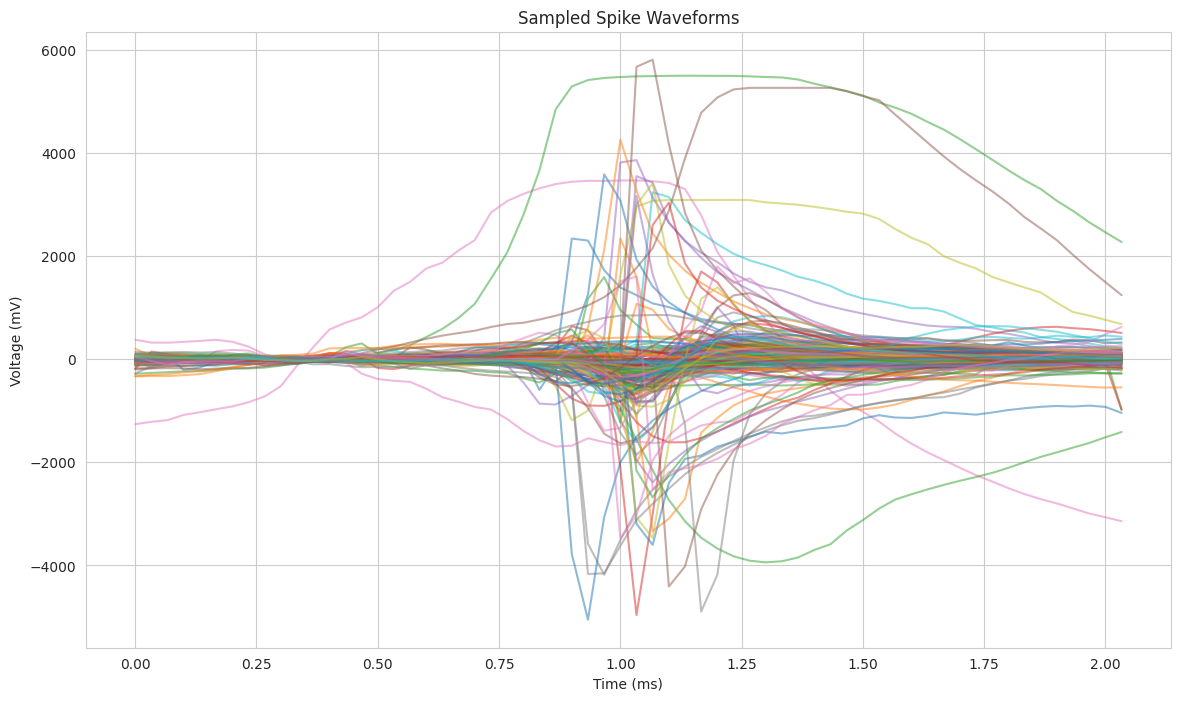

In [5]:
# Plot sampled spike waveforms

plt.figure(figsize=(14, 8))
sample_rows = np.random.choice(
    df.index,
    200,
    replace=False
)
for row in sample_rows:
    plt.plot(
        time_ms,
        df.iloc[row, :],
        alpha=0.5,
        linewidth=1.5
    )
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Sampled Spike Waveforms")
plt.show()

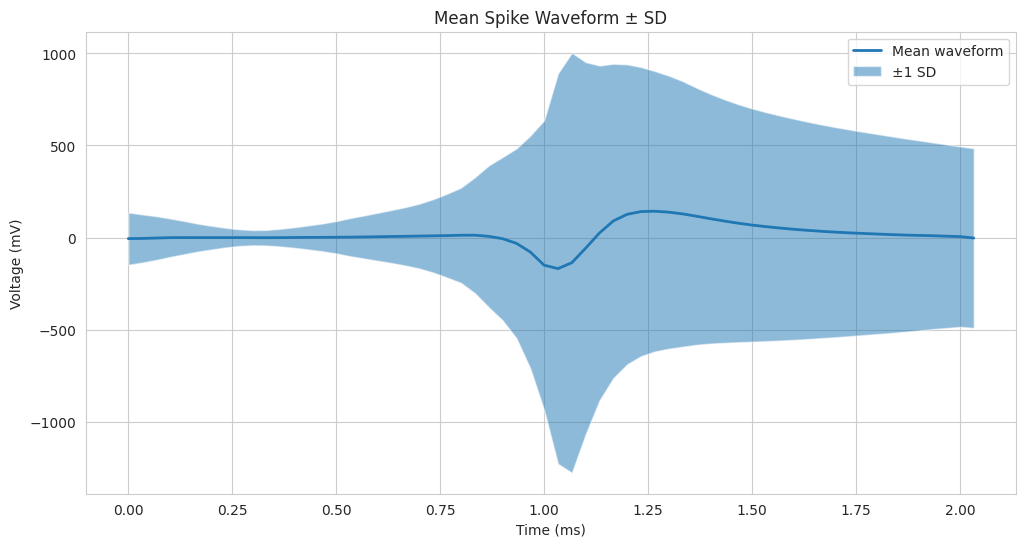

In [6]:
# Mean waveform

mean_waveform = df.mean(axis=0)
std_waveform = df.std(axis=0)
plt.figure(figsize=(12,6))
plt.plot(
    time_ms,
    mean_waveform,
    linewidth=2,
    label="Mean waveform"
)
plt.fill_between(
    time_ms,
    mean_waveform - std_waveform,
    mean_waveform + std_waveform,
    alpha=0.5,
    label="±1 SD"
)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Mean Spike Waveform ± SD")
plt.legend()
plt.show()

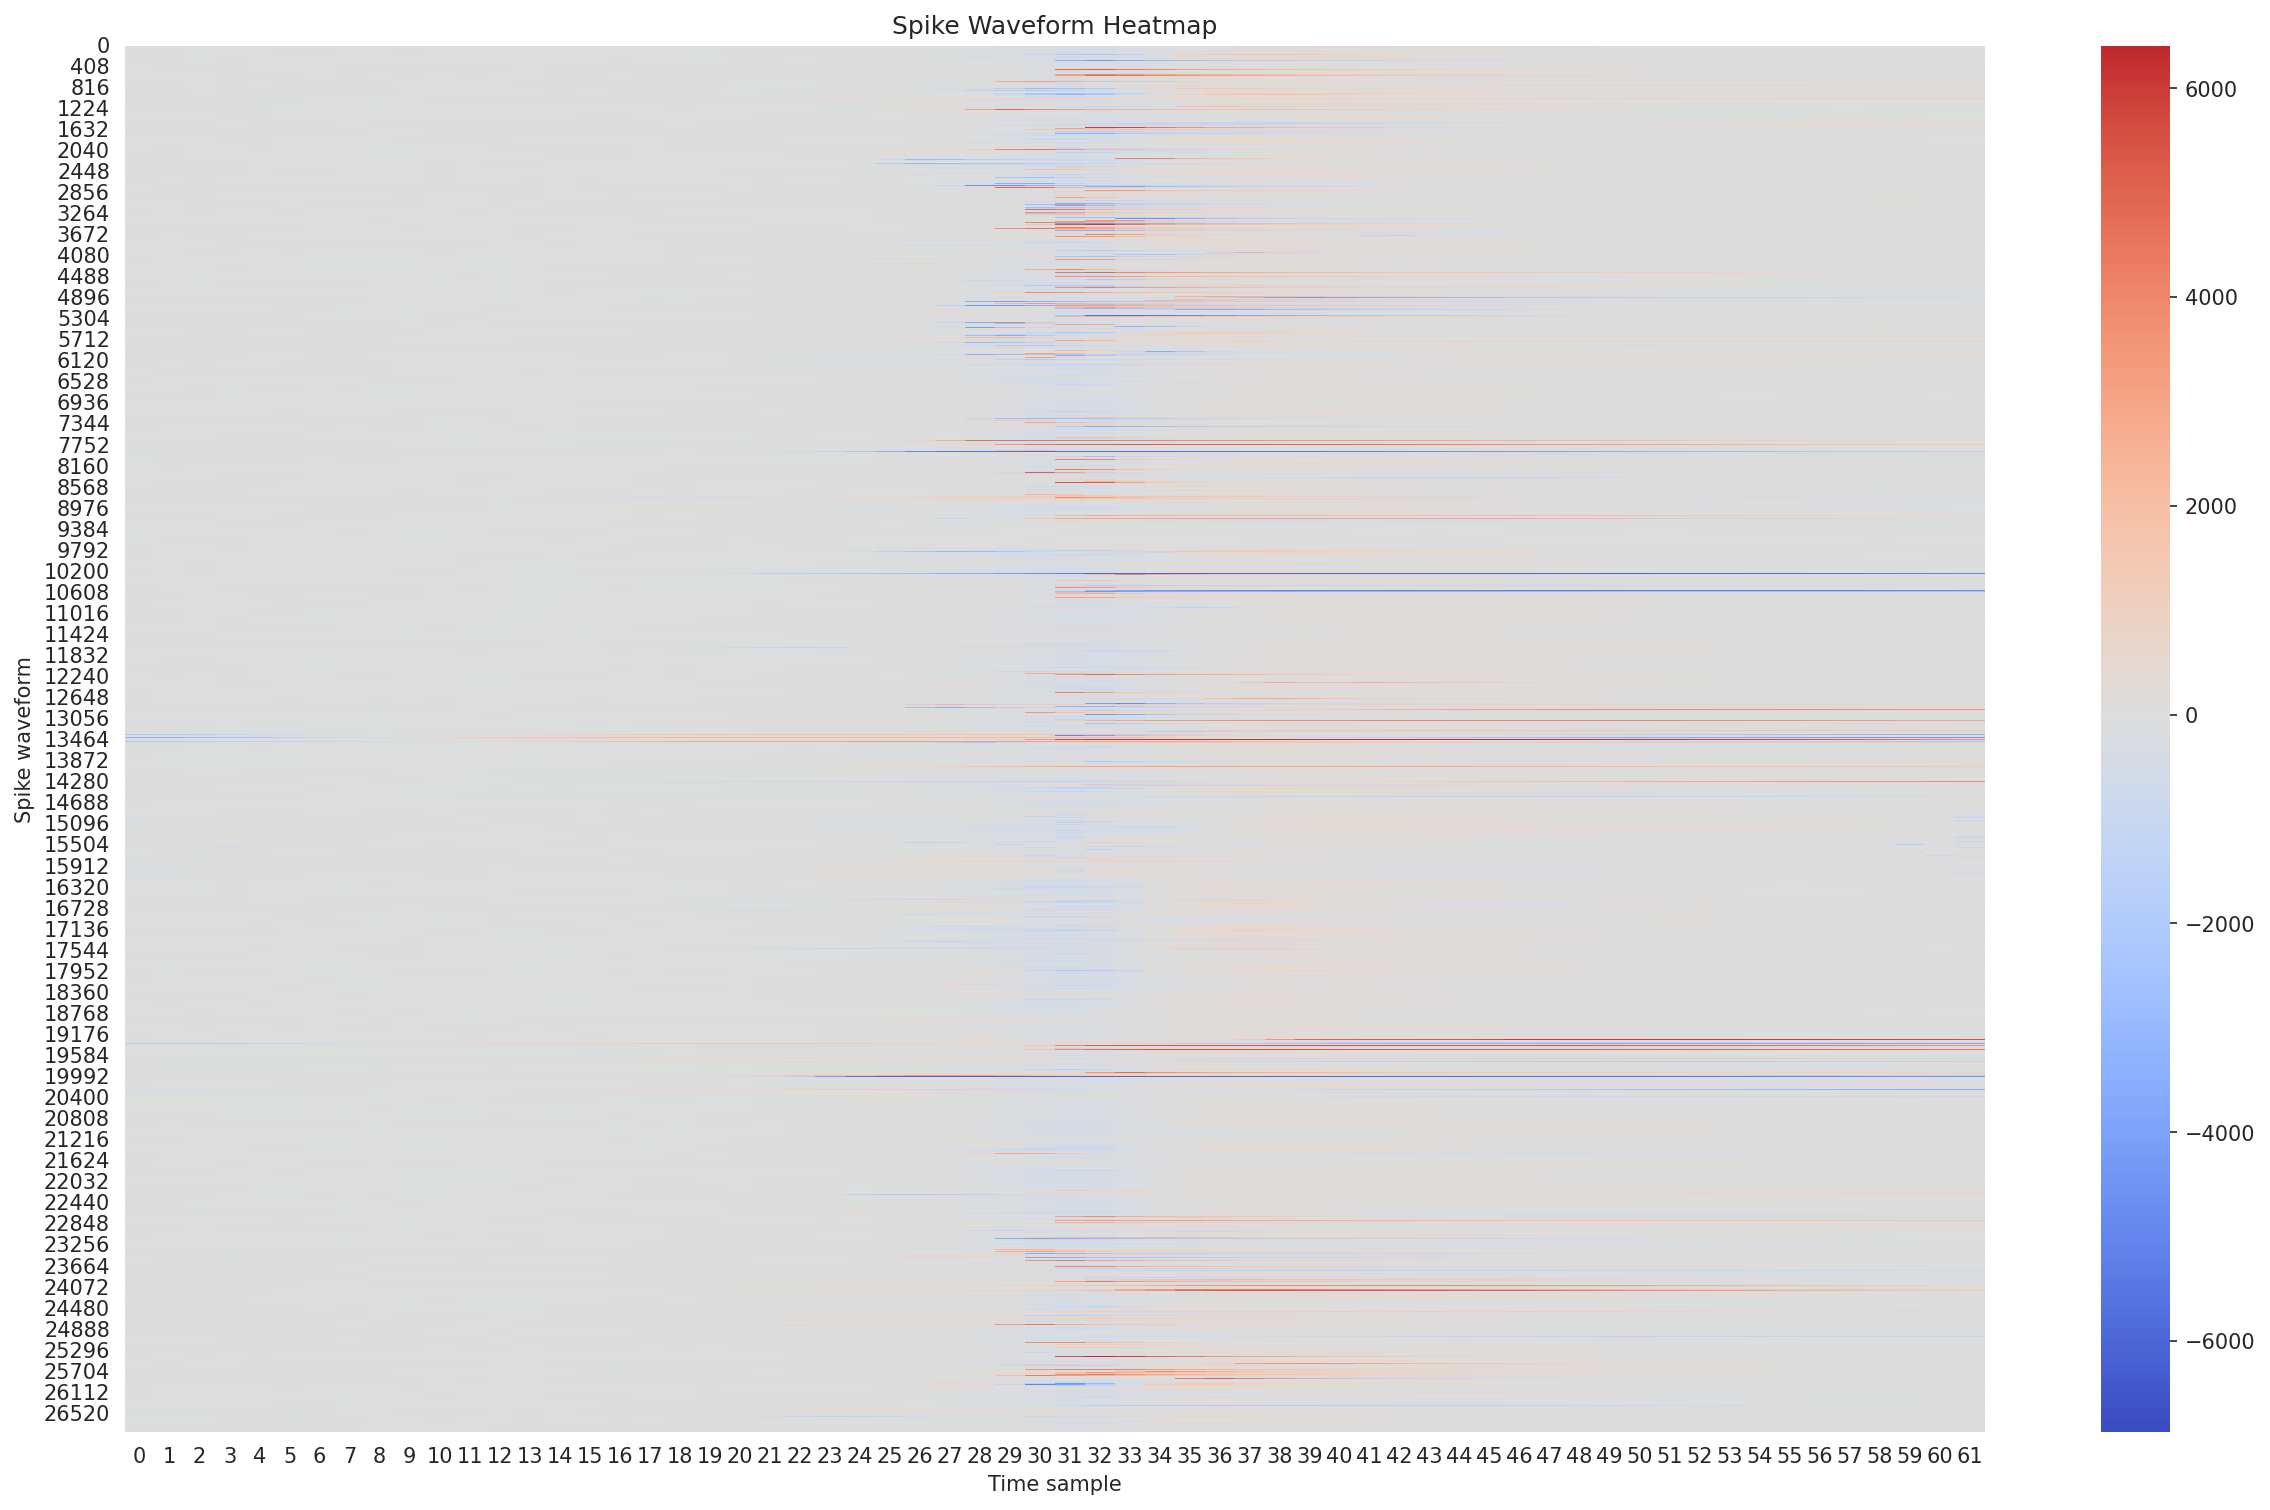

In [7]:
# Heatmap

plt.figure(figsize=(20, 12), dpi=150)
sns.heatmap(
    df,
    cmap="coolwarm",
    center=0,
    cbar=True
)
plt.xlabel("Time sample")
plt.ylabel("Spike waveform")
plt.title("Spike Waveform Heatmap")
plt.show()

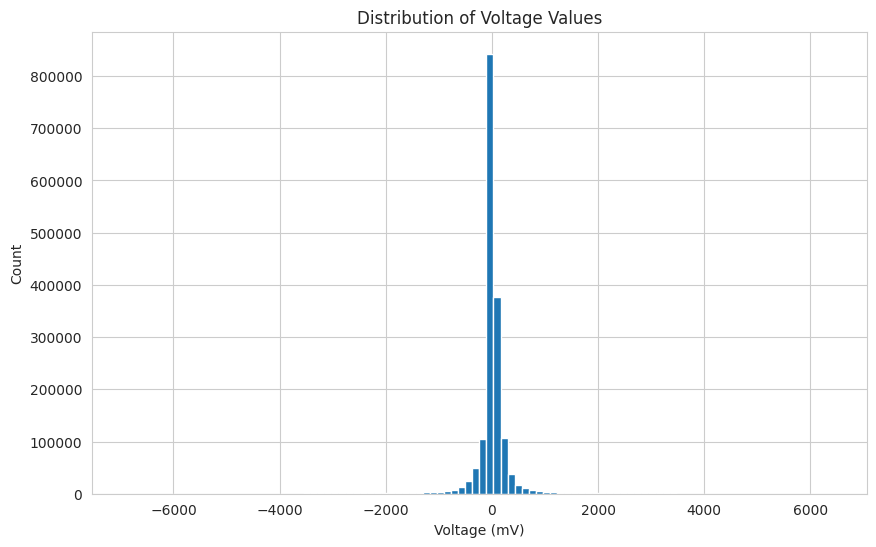

In [8]:
# Distribution of all voltage values

plt.figure(figsize=(10, 6))
plt.hist(
    df.values.flatten(),
    bins=100
)
plt.xlabel("Voltage (mV)")
plt.ylabel("Count")
plt.title("Distribution of Voltage Values")
plt.show()

In [9]:
# Row-wise waveform feature

baseline_window = 5
baseline = df.iloc[:, :baseline_window].mean(axis=1)
min_value = df.min(axis=1)
max_value = df.max(axis=1)
min_sample = df.idxmin(axis=1)
max_sample = df.idxmax(axis=1)
min_time_ms = time_ms[min_sample]
max_time_ms = time_ms[max_sample]
peak_to_peak = max_value - min_value
mean_value = df.mean(axis=1)
std_value = df.std(axis=1)
negative_peak_abs = min_value.abs()
positive_peak_abs = max_value.abs()
dominant_polarity = np.where(
    positive_peak_abs > negative_peak_abs,
    "positive",
    "negative"
)
biphasic = (
    (min_value < 0) &
    (max_value > 0)
)
features_df = pd.DataFrame({
    "baseline_mV": baseline,
    "min_mV": min_value,
    "max_mV": max_value,
    "peak_to_peak_mV": peak_to_peak,
    "std_mV": std_value,
    "time_to_min_ms": min_time_ms,
    "time_to_max_ms": max_time_ms,
    "dominant_polarity": dominant_polarity,
    "biphasic": biphasic
})
display(features_df.head())

,baseline_mV,min_mV,max_mV,peak_to_peak_mV,std_mV,time_to_min_ms,time_to_max_ms,dominant_polarity,biphasic
0,13.861667,-140.758333,3392.475,3533.233333,830.783209,2.033333,1.033333,positive,True
1,14.436667,-304.643333,382.590,687.233333,140.462249,0.900000,1.133333,positive,True
2,-21.075000,-230.988333,299.845,530.833333,113.983199,0.866667,1.133333,positive,True
3,-13.931667,-323.471667,260.295,583.766667,114.042557,0.900000,1.166667,negative,True
4,5.731667,-366.855000,171.345,538.200000,81.777585,1.033333,1.166667,negative,True


In [10]:
# Save features

features_output = "../outputs/waveform_features.csv"
features_df.to_csv(
    features_output,
    index=False
)
print("Saved waveform features:")
print(features_output)

Saved waveform features:
../outputs/waveform_features.csv


In [19]:
output_pdf = "../outputs/initial_spike_waveform_plots_with_features.pdf"
with PdfPages(output_pdf) as pdf:

    print("Adding feature summary table to PDF...")
    # Plot 0: feature summary table
    
    summary_table = features_df.describe().round(4)
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis("off")
    table = ax.table(
        cellText=summary_table.values,
        rowLabels=summary_table.index,
        colLabels=summary_table.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.1, 1.5)

    ax.set_title(
        "Summary Statistics of Row-wise Neuron Response Features",
        fontsize=14,
        pad=20
    )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)
    
    # plt.title("Summary Statistics of Row-wise Neuron Response Features")
    # pdf.savefig(fig)
    # plt.close(fig)
    
    # Plot 1: sampled neuron responses
    fig = plt.figure(figsize=(14, 8))
    sample_rows = np.random.choice(
        df.index,
        200,
        replace=False
    )
    for row in sample_rows:
        plt.plot(
            time_ms,
            df.iloc[row, :],
            alpha=0.5,
            linewidth=1.5
        )
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.title("Sampled Neuron Responses")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # Plot 2: mean response ± SD
    mean_response = df.mean(axis=0)
    std_response = df.std(axis=0)
    fig = plt.figure(figsize=(12, 6))
    plt.plot(
        time_ms,
        mean_response,
        linewidth=2,
        label="Mean response"
    )
    plt.fill_between(
        time_ms,
        mean_response - std_response,
        mean_response + std_response,
        alpha=0.5,
        label="±1 SD"
    )
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.title("Mean Neuron Response ± SD")
    plt.legend()
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

    # Plot 3: heatmap
    fig = plt.figure(figsize=(20, 12), dpi=200)
    plt.style.use("default")
    sns.heatmap(
        df,
        # cmap="coolwarm",
        cmap = "seismic",
        cbar=True,
        robust=True
    )
    plt.xlabel("Time sample")
    plt.ylabel("Neuron response")
    plt.title("Neuron Response Heatmap")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Plot 4: voltage distribution
    fig = plt.figure(figsize=(10, 6))
    plt.hist(
        df.values.flatten(),
        bins=100
    )
    plt.xlabel("Voltage (mV)")
    plt.ylabel("Count")
    plt.title("Distribution of Voltage Values")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)
print("Saved PDF report:")
print(output_pdf)

Adding feature summary table to PDF...
Saved PDF report:
../outputs/initial_spike_waveform_plots_with_features.pdf


In [20]:
# Open the new file

os.system(
    "xdg-open ../outputs/initial_spike_waveform_plots_with_features.pdf"
)

0